# Z-sampling convergence study — Au [110]

How does diffraction-pattern accuracy degrade as z-sampling becomes coarser?

- **Ground truth**: KG ODE with fine z-sampling (many slices per unit cell, tight tolerances)
- **Test methods**: Fresnel MS, Angular Spectrum, WPM, KG FWD Lanczos
- **Input wave**: Plane wave
- **z-samplings**: 1 slice/cell (atom plane), 2, 4, 8, 16, 32 slices/cell
- **Metric**: Relative L2 norm of diffraction pattern difference vs ground truth

In [1]:
%matplotlib widget

import os
from time import perf_counter
import functools

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
)
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Build crystal and common objects

In [2]:
# --- Parameters ---
energy = 200e3              # 200 keV
a_Au = 4.076                # lattice parameter (Å)
sigma_Au = 0.065            # RMS thermal displacement (Å)

# --- Build Au [110] orthogonal cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)       # [110] repeat distance ≈ 2.884 Å
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

# Target ~40 Å lateral, ~400 Å thick
nx = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
nz = int(np.ceil(100 / z_period))

supercell = unit_cell * (nx, ny, nz)
total_thickness = float(supercell.cell[2, 2])

wavelength = energy2wavelength(energy)
print(f"Au [110], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Unit cell z-period = {z_period:.4f} Å")
print(f"Supercell: {nx}×{ny}×{nz}, total thickness = {total_thickness:.1f} Å")

# --- Z-sampling levels to test (slices per unit cell) ---
slices_per_cell_list = [1, 2, 4, 8, 16, 32, 128]
dz_list = [z_period / s for s in slices_per_cell_list]

print(f"\nZ-sampling levels:")
print(f"{'Slices/cell':>12s} {'dz (Å)':>10s} {'Total slices':>14s}")
print("-" * 38)
for spc, dz in zip(slices_per_cell_list, dz_list):
    n_sl = int(np.round(total_thickness / dz))
    print(f"{spc:>12d} {dz:>10.4f} {n_sl:>14d}")

Au [110], 200 keV, λ = 0.0251 Å
Unit cell z-period = 2.8836 Å
Supercell: 4×4×35, total thickness = 100.9 Å

Z-sampling levels:
 Slices/cell     dz (Å)   Total slices
--------------------------------------
           1     2.8836             35
           2     1.4418             70
           4     0.7209            140
           8     0.3604            280
          16     0.1802            560
          32     0.0901           1120
         128     0.0225           4480


## KG FWD Lanczos propagator

In [3]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=130):
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)
    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    @functools.partial(jax.jit, static_argnums=(4, 5, 6))
    def _propagate_one_slice(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
        def matvec(v):
            vg = v.reshape(ny_, nx_)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0sq * conv - kpsq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, m_)

    for i in range(pot_arr.shape[0]):
        state = _propagate_one_slice(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

print("Lanczos propagator defined.")

Lanczos propagator defined.


## Compute ground truth (KG ODE, finest z-sampling)

Use the finest z-sampling as reference. The adaptive ODE solver provides
additional sub-step accuracy within each slice.

In [4]:
# Use finest z-sampling for ground truth
ref_slices_per_cell = slices_per_cell_list[-1]
ref_dz = z_period / ref_slices_per_cell
ref_n_slices = int(np.round(total_thickness / ref_dz))

print(f"Ground truth: KG ODE, dz = {ref_dz:.4f} Å, {ref_n_slices} slices")
print(f"Building potential...")

# Build fine-sampled potential
pot_ref_abtem = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=ref_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(pot_ref_abtem.gpts)
sampling = (float(pot_ref_abtem.sampling[0]), float(pot_ref_abtem.sampling[1]))

pot_ref_arr = jnp.array(cupy.asnumpy(pot_ref_abtem.build(lazy=False).array / ref_dz))

# Plane-wave input on the simulation grid
ny, nx = pot_ref_arr.shape[1:]
probe_array = jnp.ones((ny, nx), dtype=jnp.complex128)

del pot_ref_abtem
cupy.get_default_memory_pool().free_all_blocks()

print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Potential shape: {pot_ref_arr.shape}")
print(f"\nRunning KG ODE ground truth (rtol=1e-9, atol=1e-11)...")

t0 = perf_counter()
ew_gt, _, dp_gt_raw, _ = simulate_kg_ode_full(
    pot_ref_arr, probe_array, ref_dz, energy, sampling,
    rtol=1e-9, atol=1e-11,
)
dp_gt = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew_gt)))) ** 2
t_gt = perf_counter() - t0

del pot_ref_arr

print(f"Done in {t_gt:.1f}s")
print(f"Ground truth DP max: {dp_gt.max():.4e}")

Ground truth: KG ODE, dz = 0.0225 Å, 4480 slices
Building potential...
Grid: (116, 116), sampling = (0.0994, 0.0994) Å
Potential shape: (4480, 116, 116)

Running KG ODE ground truth (rtol=1e-9, atol=1e-11)...
Done in 84.2s
Ground truth DP max: 6.6297e+07


## Sweep z-sampling for all 4 methods

For each `dz`, rebuild the potential at that slice thickness and run
Fresnel MS, Angular Spectrum, WPM, and KG FWD Lanczos. Compute
Rel L2 of diffraction pattern vs ground truth.

In [5]:
method_names = ["Fresnel MS", "Angular Spectrum", "WPM", "KG FWD Lanczos"]
all_method_names = method_names.copy()

# Results: {method_name: [rel_l2 for each dz]}
rel_l2_results = {name: [] for name in all_method_names}
rms_results = {name: [] for name in all_method_names}
timings = {name: [] for name in all_method_names}

for spc, dz in zip(slices_per_cell_list, dz_list):
    n_slices = int(np.round(total_thickness / dz))
    print(f"\n{'='*60}")
    print(f"dz = {dz:.4f} Å ({spc} slices/cell, {n_slices} total slices)")
    print(f"{'='*60}")

    # Build potential at this slice thickness
    pot_abtem = abtem.Potential(
        supercell, gpts=gpts, slice_thickness=dz,
        projection="finite", parametrization="lobato",
    )
    pot_arr = jnp.array(cupy.asnumpy(pot_abtem.build(lazy=False).array / dz))
    del pot_abtem
    cupy.get_default_memory_pool().free_all_blocks()

    # Propagation kernels for this dz
    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz, energy=energy))

    methods_to_run = {
        "Fresnel MS":       lambda: simulate_fresnel_as(pot_arr, probe_array, fk, dz, energy),
        "Angular Spectrum": lambda: simulate_fresnel_as(pot_arr, probe_array, ak, dz, energy),
        "WPM":              lambda: simulate_wpm(pot_arr, probe_array, dz, energy, sampling),
        "KG FWD Lanczos":   lambda: (simulate_kg_fwd_lanczos(pot_arr, probe_array, dz, energy, sampling), None, None),
    }

    for name in all_method_names:
        print(f"  {name}...", end=" ", flush=True)
        t0 = perf_counter()
        result = methods_to_run[name]()
        elapsed = perf_counter() - t0

        ew = np.asarray(result[0])
        dp = np.abs(np.fft.fftshift(np.fft.fft2(ew))) ** 2
        dp_diff = dp - dp_gt
        rel_l2 = float(np.linalg.norm(dp_diff) / np.linalg.norm(dp_gt))
        rms = float(np.sqrt(np.mean(dp_diff**2)))

        rel_l2_results[name].append(rel_l2)
        rms_results[name].append(rms)
        timings[name].append(elapsed)

        print(f"{elapsed:.1f}s, Rel L2 = {rel_l2:.4e}")

    del pot_arr, fk, ak

print(f"\n{'='*60}")
print("Sweep complete.")



dz = 2.8836 Å (1 slices/cell, 35 total slices)
  Fresnel MS... 0.4s, Rel L2 = 1.4668e-02
  Angular Spectrum... 0.1s, Rel L2 = 1.2874e-02
  WPM... 2.5s, Rel L2 = 1.3240e-02
  KG FWD Lanczos... 1.8s, Rel L2 = 1.8257e-01

dz = 1.4418 Å (2 slices/cell, 70 total slices)
  Fresnel MS... 0.3s, Rel L2 = 3.3631e-02
  Angular Spectrum... 0.1s, Rel L2 = 3.3873e-02
  WPM... 1.2s, Rel L2 = 3.4563e-02
  KG FWD Lanczos... 1.9s, Rel L2 = 1.5012e-01

dz = 0.7209 Å (4 slices/cell, 140 total slices)
  Fresnel MS... 0.5s, Rel L2 = 1.6026e-02
  Angular Spectrum... 0.4s, Rel L2 = 1.7206e-02
  WPM... 2.3s, Rel L2 = 1.7744e-02
  KG FWD Lanczos... 2.4s, Rel L2 = 6.6833e-02

dz = 0.3604 Å (8 slices/cell, 280 total slices)
  Fresnel MS... 1.0s, Rel L2 = 2.0103e-02
  Angular Spectrum... 0.7s, Rel L2 = 1.2156e-02
  WPM... 4.5s, Rel L2 = 1.2533e-02
  KG FWD Lanczos... 3.9s, Rel L2 = 1.2162e-02

dz = 0.1802 Å (16 slices/cell, 560 total slices)
  Fresnel MS... 1.0s, Rel L2 = 1.2237e-02
  Angular Spectrum... 0.9s, Re

## Convergence plot

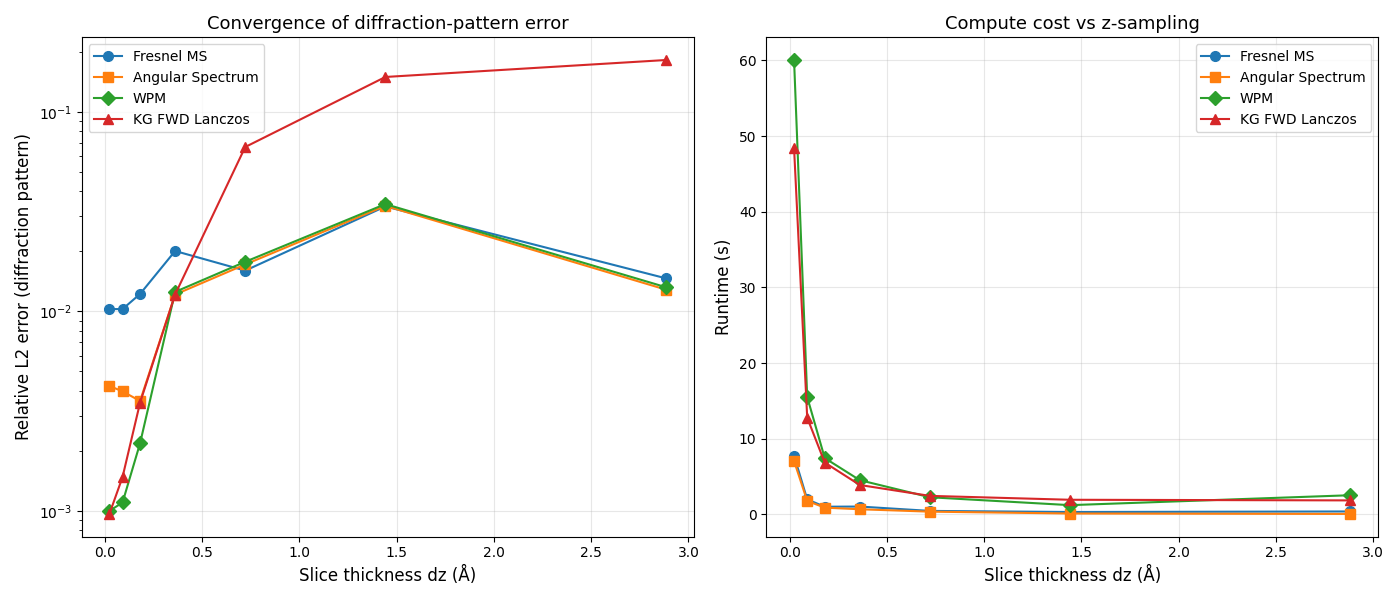

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

markers = {'Fresnel MS': 'o', 'Angular Spectrum': 's', 'WPM': 'D',
           'KG FWD Lanczos': '^', 'KG ODE': 'v'}
colors = {'Fresnel MS': 'C0', 'Angular Spectrum': 'C1', 'WPM': 'C2',
          'KG FWD Lanczos': 'C3', 'KG ODE': 'C4'}

dz_arr = np.array(dz_list)

# --- Left panel: Rel L2 vs dz ---
for name in all_method_names:
    ax1.semilogy(dz_arr, rel_l2_results[name], f'-{markers[name]}',
                 color=colors[name], label=name, markersize=7, linewidth=1.5)

ax1.set_xlabel("Slice thickness dz (Å)", fontsize=12)
ax1.set_ylabel("Relative L2 error (diffraction pattern)", fontsize=12)
ax1.set_title("Convergence of diffraction-pattern error", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# --- Right panel: runtime vs dz ---
for name in all_method_names:
    ax2.plot(dz_arr, timings[name], f'-{markers[name]}',
             color=colors[name], label=name, markersize=7, linewidth=1.5)

ax2.set_xlabel("Slice thickness dz (Å)", fontsize=12)
ax2.set_ylabel("Runtime (s)", fontsize=12)
ax2.set_title("Compute cost vs z-sampling", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Summary table

In [7]:
print(f"Au [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å")
print(f"Ground truth: KG ODE at dz = {ref_dz:.4f} Å ({ref_slices_per_cell} slices/cell)\n")

# Header
hdr = f"{'dz (Å)':>8s} {'sl/cell':>8s}"
for name in all_method_names:
    hdr += f" {name:>17s}"
print(hdr)
print("-" * len(hdr))

for i, (spc, dz) in enumerate(zip(slices_per_cell_list, dz_list)):
    row = f"{dz:>8.4f} {spc:>8d}"
    for name in all_method_names:
        row += f" {rel_l2_results[name][i]:>17.4e}"
    print(row)

Au [110], 200 keV, 101 Å
Ground truth: KG ODE at dz = 0.0225 Å (128 slices/cell)

  dz (Å)  sl/cell        Fresnel MS  Angular Spectrum               WPM    KG FWD Lanczos
-----------------------------------------------------------------------------------------
  2.8836        1        1.4668e-02        1.2874e-02        1.3240e-02        1.8257e-01
  1.4418        2        3.3631e-02        3.3873e-02        3.4563e-02        1.5012e-01
  0.7209        4        1.6026e-02        1.7206e-02        1.7744e-02        6.6833e-02
  0.3604        8        2.0103e-02        1.2156e-02        1.2533e-02        1.2162e-02
  0.1802       16        1.2237e-02        3.5545e-03        2.1805e-03        3.4854e-03
  0.0901       32        1.0275e-02        3.9712e-03        1.1001e-03        1.4760e-03
  0.0225      128        1.0278e-02        4.2286e-03        9.9759e-04        9.6372e-04
